In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :png
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "L3J1bi9tZWRpYS9hbGYvZGF0b3MvbWlzcmVwb3NpdG9yaW9zL2RvY2VuY2lhL2VjdWFjaW9uZXMtZGlmZXJlbmNpYWxlcy1wcmFjdGljYXMtanVsaWE="
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using LinearAlgebra
A = [-0.04 0.01; 0.04 -0.04]
λ = eigvals(A)

2-element Vector{Float64}:
 -0.06
 -0.019999999999999997

In [3]:
V = eigvecs(A)

2×2 Matrix{Float64}:
 -0.447214  0.447214
  0.894427  0.894427

In [4]:
using SymPyPythonCall
As = Sym[-4 1; 4 -4] / 100  # -0.04, 0.01, 0.04, -0.04
As.eigenvects()

2-element Vector{Tuple{Sym{PythonCall.Py}, Sym{PythonCall.Py}, Vector{Matrix{Sym{PythonCall.Py}}}}}:
 (-3/50, 1, [[-1/2; 1;;]])
 (-1/50, 1, [[1/2; 1;;]])

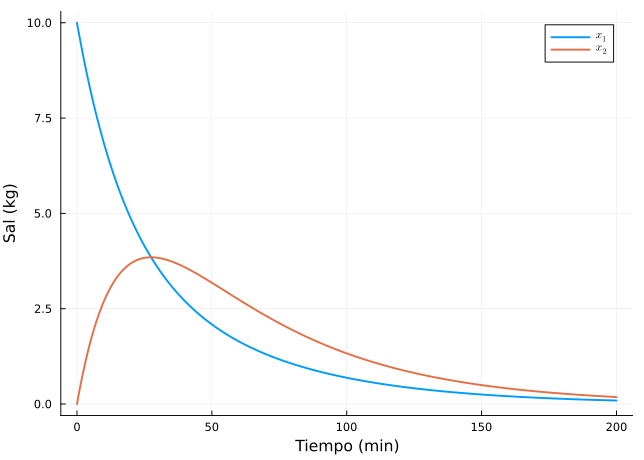

In [5]:
using Plots, LaTeXStrings
x0 = [10.0, 0.0]
x(t) = exp(A * t) * x0
ts = 0:0.5:200
X = hcat(x.(ts)...)
plot(ts, X', lw = 2, label = [L"x_1" L"x_2"],
    xlab = "Tiempo (min)", ylab = "Sal (kg)")

In [6]:
imax = argmax(X[2, :])
(t_max = ts[imax], x2_max = round(X[2, imax], digits = 3))

(t_max = 27.5, x2_max = 3.849)

In [7]:
using SymPyPythonCall
@syms t
As = Sym[-1//25//4 1//100; 1//25 -1//25//1]  # -0.04, 0.01, 0.04, -0.04
As = Sym[-4 1; 4 -4] / 100
exp(As * t)

2×2 Matrix{Sym{PythonCall.Py}}:
 exp(-t/50)/2 + exp(-3*t/50)/2  exp(-t/50)/4 - exp(-3*t/50)/4
     exp(-t/50) - exp(-3*t/50)  exp(-t/50)/2 + exp(-3*t/50)/2

In [8]:
xa(t) = exp(A * t) * [10.0, 0.0]
xb(t) = exp(A * t) * [0.0, 5.0]
xc(t) = exp(A * t) * [20.0, 15.0]
t0 = 37.0
maximum(abs.(2xa(t0) + 3xb(t0) - xc(t0)))

0.0

In [9]:
using LinearAlgebra
A = [-0.7 0.2; 0.5 -0.2]
λ = eigvals(A)

2-element Vector{Float64}:
 -0.8531128874149274
 -0.04688711258507253

In [10]:
t12 = log(2) / abs(maximum(λ))

14.783319815275272

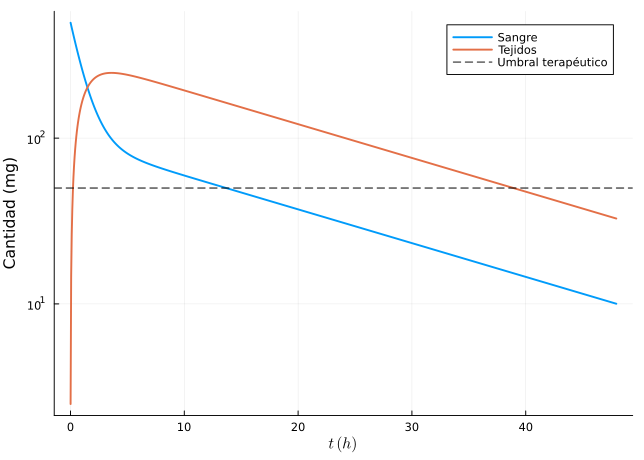

In [11]:
using Plots, LaTeXStrings
x(t) = exp(A * t) * [500.0, 0.0]
ts = 0.01:0.05:48
X = hcat(x.(ts)...)
plot(ts, X', yscale = :log10, lw = 2, label = ["Sangre" "Tejidos"],
    xlab = L"t \; (h)", ylab = "Cantidad (mg)")
hline!([50], ls = :dash, color = :black, label = "Umbral terapéutico")

In [12]:
tumbral = ts[findfirst(<(50), X[1, :])]

13.71

In [13]:
using LinearAlgebra
matrices = [[-2.0 0; 0 -1], [1.0 2; 2 1], [-1.0 2; -2 -1], [0.0 2; -2 0]]
titulos = ["Nodo estable", "Punto de silla", "Foco estable", "Centro"]
[eigvals(A) for A in matrices]

4-element Vector{Vector}:
 [-2.0, -1.0]
 [-1.0, 3.0]
 ComplexF64[-1.0 - 2.0000000000000004im, -1.0 + 2.0000000000000004im]
 ComplexF64[0.0 - 2.0000000000000004im, 0.0 + 2.0000000000000004im]

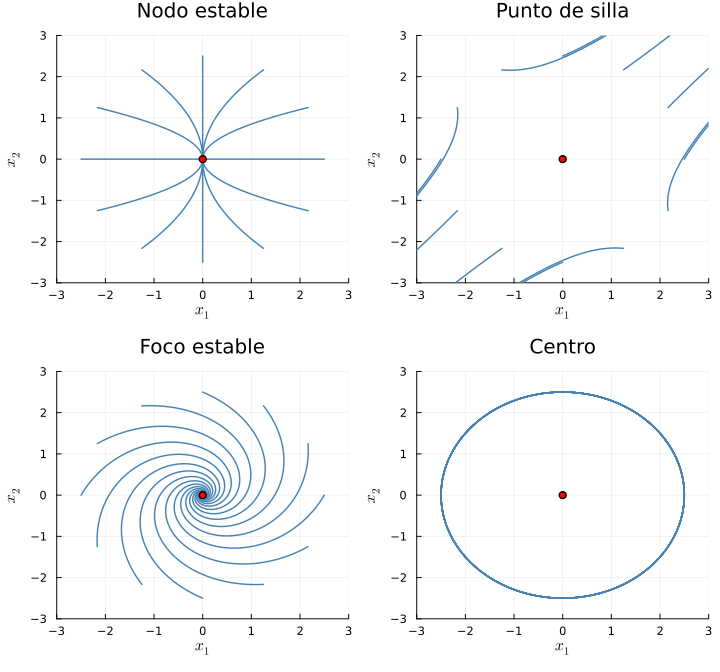

In [14]:
using Plots, LaTeXStrings, DifferentialEquations
plots = []
for (A, tit) in zip(matrices, titulos)
    plt = plot(title = tit, legend = false, xlims = (-3, 3), ylims = (-3, 3),
               xlab = L"x_1", ylab = L"x_2")
    for θ in range(0, 2π, length = 13)[1:12]
        u0 = 2.5 .* [cos(θ), sin(θ)]
        sol = solve(ODEProblem((u, p, t) -> A * u, u0, (0.0, 4.0)), saveat = 0.02)
        plot!(plt, sol[1, :], sol[2, :], lw = 1.5, color = :steelblue)
    end
    scatter!(plt, [0], [0], color = :red)
    push!(plots, plt)
end
plot(plots..., layout = (2, 2), size = (750, 700))

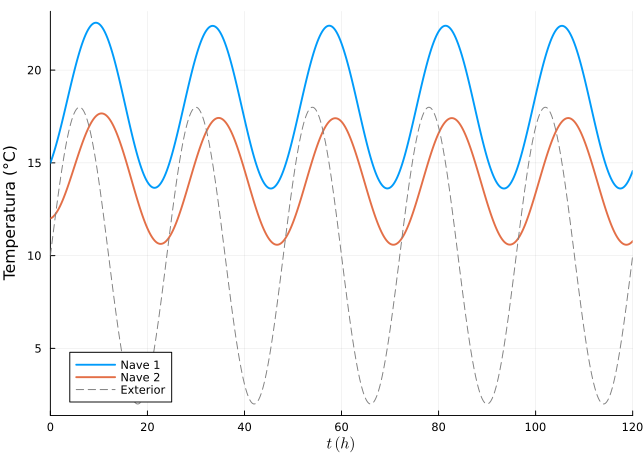

In [15]:
using Plots, LaTeXStrings, DifferentialEquations
A = [-0.3 0.1; 0.1 -0.2]
Te(t) = 10 + 8sin(2π * t / 24)
b(t) = [2 + 0.2 * Te(t), 0.1 * Te(t)]
f!(du, u, p, t) = (du .= A * u .+ b(t))
sol = solve(ODEProblem(f!, [15.0, 12.0], (0.0, 120.0)), saveat = 0.25)
plot(sol, lw = 2, label = ["Nave 1" "Nave 2"],
    xlab = L"t \; (h)", ylab = "Temperatura (°C)")
plot!(Te, 0, 120, ls = :dash, color = :gray, label = "Exterior")

In [16]:
t1 = 48.0
ds = 0.001
ss = ds/2:ds:t1
integral = sum(exp(A * (t1 - s)) * b(s) * ds for s in ss)
xvc = exp(A * t1) * [15.0, 12.0] + integral
(variacion_ctes = xvc, numerica = sol(t1))

(variacion_ctes = [14.560895202361023, 10.783584190197443], numerica = [14.562296495494602, 10.782817303188622])

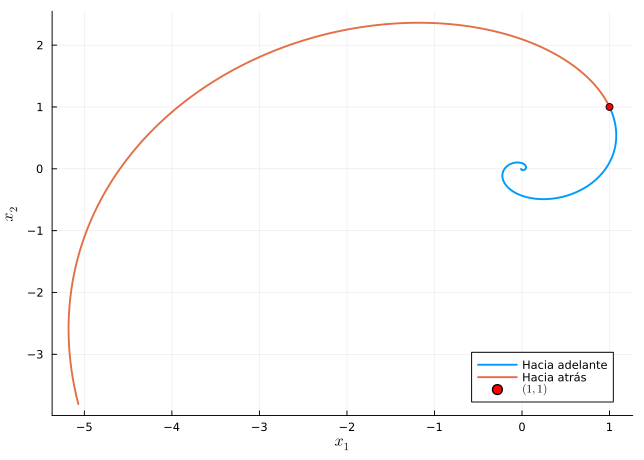

In [17]:
using Plots, LaTeXStrings, DifferentialEquations
A = [-1.0 2; -2 -1]
sol_fwd = solve(ODEProblem((u, p, t) -> A * u, [1.0, 1.0], (0.0, 5.0)), saveat = 0.01)
sol_bwd = solve(ODEProblem((u, p, t) -> A * u, [1.0, 1.0], (0.0, -1.5)), saveat = 0.01)
plot(sol_fwd[1, :], sol_fwd[2, :], lw = 2, label = "Hacia adelante",
    xlab = L"x_1", ylab = L"x_2")
plot!(sol_bwd[1, :], sol_bwd[2, :], lw = 2, label = "Hacia atrás")
scatter!([1], [1], color = :red, label = L"(1,1)")